We first have to import the API data into a local csv. This is to avoid having to rerun this process every single time as our API call returns more than 1M rows of data.

In [1]:
import requests
import duckdb
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:

def fetch_weather_data(csv_path):
    """Downloads weather data from the ASOS Mesonet API."""
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?"
        "data=all&tz=UTC&format=onlycomma&latlon=yes&"
        "sts=2023-01-01T00:00Z&ets=2026-01-01T00:00Z&"
        "station=ATL&station=DFW&station=DEN&station=ORD&station=LAX&"
        "station=JFK&station=CLT&station=LAS&station=MCO&station=MIA&"
        "station=PHX&station=SEA&station=SFO&station=EWR&station=IAH&"
        "station=BOS&station=MSP&station=FLL&station=LGA&station=DTW&"
        "station=PHL&station=SLC&station=BWI&station=IAD&station=SAN&"
        "station=DCA&station=TPA&station=BNA&station=AUS&station=HNL&"
        "station=MDW&station=MSY&station=RDU&station=SJC&station=SNA&"
        "station=PDX&station=STL&station=SMF&station=HOU&station=BUR&"
        "station=MKE&station=OAK&station=IND&station=CVG&station=SAT&"
        "station=CLE&station=PIT&station=PBI&station=JAX"
    )
    
    print(f"Starting data download to {csv_path}...")
    with requests.get(url, stream=True) as response:
        response.raise_for_status()
        with open(csv_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=65536):
                f.write(chunk)
    print("Download complete.")

fetch_weather_data("temp_weather_data.csv")


In [2]:
def ingest_to_duckdb(csv_path, db_path):
    """Loads the CSV data into a DuckDB table."""
    print(f"Ingesting {csv_path} into DuckDB database: {db_path}")
    
    # Connect to the database (creates it if it doesn't exist)
    con = duckdb.connect(db_path)
    
    try:
        # read_csv_auto handles headers and type detection
        # comment='#' skips the metadata lines typical of ASOS reports
        con.execute(f"""
            CREATE OR REPLACE TABLE weather AS 
            SELECT * FROM read_csv_auto('{csv_path}', comment='#');
        """)
        
        count = con.execute("SELECT count(*) FROM weather").fetchone()[0]
        print(f"Success! Ingested {count:,} rows.")
    finally:
        con.close()


ingest_to_duckdb("temp_weather_data.csv", "weather_data.duckdb")

Ingesting temp_weather_data.csv into DuckDB database: weather_data.duckdb
Success! Ingested 1,313,941 rows.


The data cleaning pipeline focused on standardizing raw meteorological reports into a high-fidelity format for predictive modeling. Key transformations included:

* **Numeric Standardization**: Raw strings and "M" placeholders were converted into double-precision floats for temperature, pressure, and visibility, ensuring the model receives consistent mathematical inputs.
* **Weather Code Translation**: Complex weather strings were parsed using regular expressions to create a tiered intensity scale (0-3) for thunderstorms, capturing the severity of the weather rather than just its presence.
* **Ceiling Height Synthesis**: The logic aggregated four distinct sky-layer columns into a single feature by identifying the altitude of the lowest cloud layer reporting "broken," "overcast," or "vertical visibility" conditions.
* **Temporal Alignment**: Timestamps were rounded to the nearest hour using time-bucketing to align weather observations with flight departure and arrival schedules.
* **Deterministic Deduplication**: To resolve instances with multiple reports in a single hour, the pipeline retained only the most recent observation per station-hour to prevent data leakage and ensure the most up-to-date conditions are used for training.

In [3]:
con = duckdb.connect("weather_data.duckdb")

con.execute("""
    CREATE OR REPLACE TABLE weather_cleaned AS
    WITH raw_processed AS (
        SELECT 
            station AS STATION,
            CAST(valid AS TIMESTAMP) AS valid_ts,
            EXTRACT(year FROM valid_ts) AS YEAR,
            EXTRACT(month FROM valid_ts) AS MONTH,
            EXTRACT(day FROM valid_ts) AS DAY,
            EXTRACT(hour FROM (valid_ts + INTERVAL '30 minutes')) AS HOUR,
            
            CAST(drct AS DOUBLE) AS WIND_ANGLE,
            CAST(sknt AS DOUBLE) AS WIND_SPEED,
            CAST(gust AS DOUBLE) AS WIND_GUST,
            CAST(vsby AS DOUBLE) AS VISIBILITY,
            CAST(tmpf AS DOUBLE) AS AIR_TEMP,
            CAST(dwpf AS DOUBLE) AS DEW_POINT_TEMP,
            CAST(mslp AS DOUBLE) AS PRESSURE,
            
            -- Handle 'T' (Trace)
            CAST(CASE WHEN p01i = 'T' THEN '0.0001' ELSE p01i END AS DOUBLE) AS PRECIPITATION,
            
            CASE 
                WHEN wxcodes LIKE '%+TS%' THEN 3
                WHEN wxcodes LIKE '%-TS%' THEN 1
                WHEN wxcodes LIKE '%TS%' THEN 2
                ELSE 0 
            END AS HAS_THUNDERSTORM,

            list_min([
                CASE WHEN skyc1 IN ('BKN', 'OVC', 'VV') THEN CAST(skyl1 AS DOUBLE) END,
                CASE WHEN skyc2 IN ('BKN', 'OVC', 'VV') THEN CAST(skyl2 AS DOUBLE) END,
                CASE WHEN skyc3 IN ('BKN', 'OVC', 'VV') THEN CAST(skyl3 AS DOUBLE) END,
                CASE WHEN skyc4 IN ('BKN', 'OVC', 'VV') THEN CAST(skyl4 AS DOUBLE) END
            ]) AS CEILING_HEIGHT
        FROM weather
    )
    SELECT 
        *,
        COALESCE(CASE WHEN WIND_GUST > 0 THEN 1 ELSE 0 END, 0) AS HAS_GUST,
        CASE WHEN CEILING_HEIGHT IS NOT NULL THEN 1 ELSE 0 END AS HAS_CLOUDS,
        strftime(valid_ts, '%Y-%m-%d') AS DATE
    FROM raw_processed
    QUALIFY ROW_NUMBER() OVER(
        PARTITION BY STATION, YEAR, MONTH, DAY, HOUR 
        ORDER BY valid_ts DESC
    ) = 1;
""")

con.close()

# EDA on Weather Data

In [4]:
# Connect to duckdb database
con = duckdb.connect("weather_data.duckdb")

### EDA #1: Summary Statistics on Key Variables

In [5]:
stats_query = """
SELECT 
    COUNT(*) as total_rows,
    AVG(AIR_TEMP) as avg_temp,
    AVG(WIND_SPEED) as avg_wind,
    MIN(WIND_SPEED) as min_wind,
    MAX(WIND_SPEED) as max_wind,
    AVG(VISIBILITY) as avg_vsby,
    MIN(VISIBILITY) as min_vsby,
    MAX(VISIBILITY) as max_vsby,
    MAX(PRECIPITATION) as max_precip,
    AVG(CEILING_HEIGHT) as avg_ceiling
FROM weather_cleaned;
"""
print("Summary Statistics:")
print(con.execute(stats_query).df())

Summary Statistics:
   total_rows   avg_temp  avg_wind  min_wind  max_wind  avg_vsby  min_vsby  \
0     1313680  63.448444  7.027962       0.0     170.0  9.497779       0.0   

   max_vsby  max_precip   avg_ceiling  
0   21005.0        3.98  10482.335054  


Based on the summary statistics, there are clearly some strong outliers within the data. E.g. while the documents for the METAR readings specifiy that 10 statute miles is the highest observable reading, there is clearly a number of outliers that fall outside this range. Hence, we want to bound the max values based on the METAR reading document.

In [6]:
con.execute("""
UPDATE weather_cleaned
SET 
    WIND_SPEED = CASE WHEN WIND_SPEED BETWEEN 0 AND 125 THEN WIND_SPEED ELSE NULL END,
    WIND_GUST = CASE WHEN WIND_GUST BETWEEN 0 AND 125 THEN WIND_GUST ELSE NULL END,
    WIND_ANGLE = CASE WHEN WIND_ANGLE BETWEEN 0 AND 359 THEN WIND_ANGLE ELSE NULL END,
    AIR_TEMP = CASE WHEN AIR_TEMP BETWEEN -80 AND 130 THEN AIR_TEMP ELSE NULL END,
    DEW_POINT_TEMP = CASE WHEN DEW_POINT_TEMP BETWEEN -80 AND 86 THEN DEW_POINT_TEMP ELSE NULL END,
    VISIBILITY = CASE WHEN VISIBILITY BETWEEN 0 AND 10 THEN VISIBILITY ELSE NULL END;
""")


### EDA #1.1: Summary Statistics on Key Variables (again)

In [7]:
stats_query = """
SELECT 
    COUNT(*) as total_rows,
    AVG(AIR_TEMP) as avg_temp,
    AVG(WIND_SPEED) as avg_wind,
    MIN(WIND_SPEED) as min_wind,
    MAX(WIND_SPEED) as max_wind,
    AVG(VISIBILITY) as avg_vsby,
    MIN(VISIBILITY) as min_vsby,
    MAX(VISIBILITY) as max_vsby,
    MAX(PRECIPITATION) as max_precip,
    AVG(CEILING_HEIGHT) as avg_ceiling
FROM weather_cleaned;
"""
print("Summary Statistics:")
print(con.execute(stats_query).df())

Summary Statistics:
   total_rows   avg_temp  avg_wind  min_wind  max_wind  avg_vsby  min_vsby  \
0     1313680  63.448444  7.027838       0.0     116.0  9.474638       0.0   

   max_vsby  max_precip   avg_ceiling  
0      10.0        3.98  10482.335054  


### EDA #2: Distribution Plots for Air Temperature, Wind Speed and Visibility

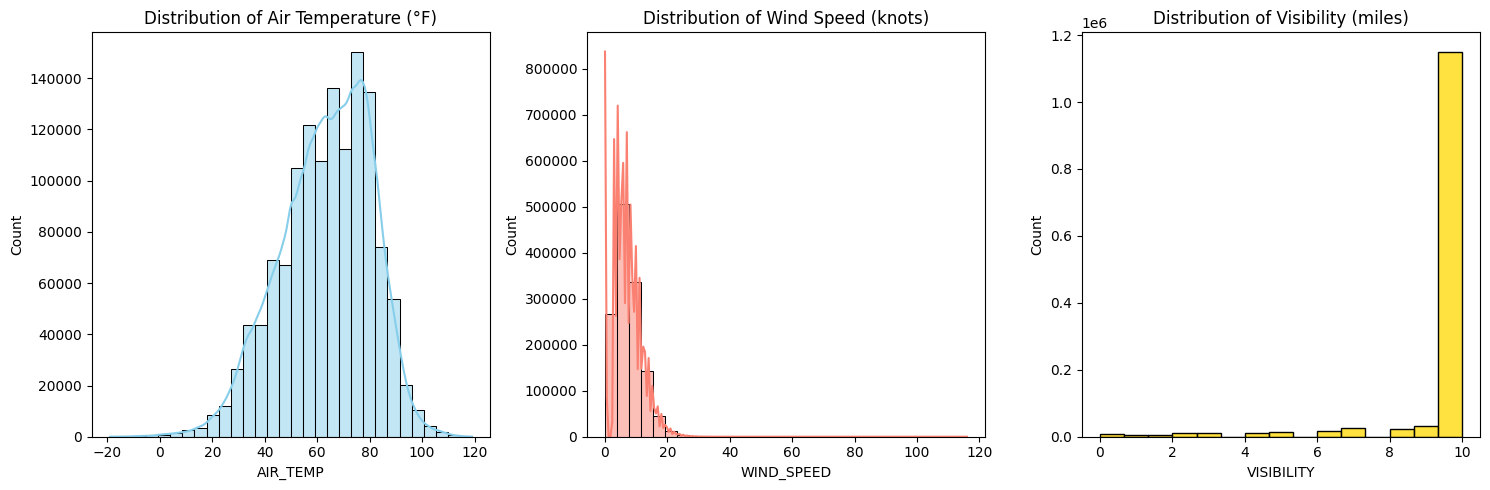

In [8]:
df = con.execute("SELECT * FROM weather_cleaned").df()

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['AIR_TEMP'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Air Temperature (°F)')

plt.subplot(1, 3, 2)
sns.histplot(df['WIND_SPEED'].dropna(), bins=30, kde=True, color='salmon')
plt.title('Distribution of Wind Speed (knots)')

plt.subplot(1, 3, 3)
sns.histplot(df['VISIBILITY'].dropna(), bins=15, color='gold')
plt.title('Distribution of Visibility (miles)')
plt.tight_layout()
plt.show()

### EDA #3: Outlier Identification

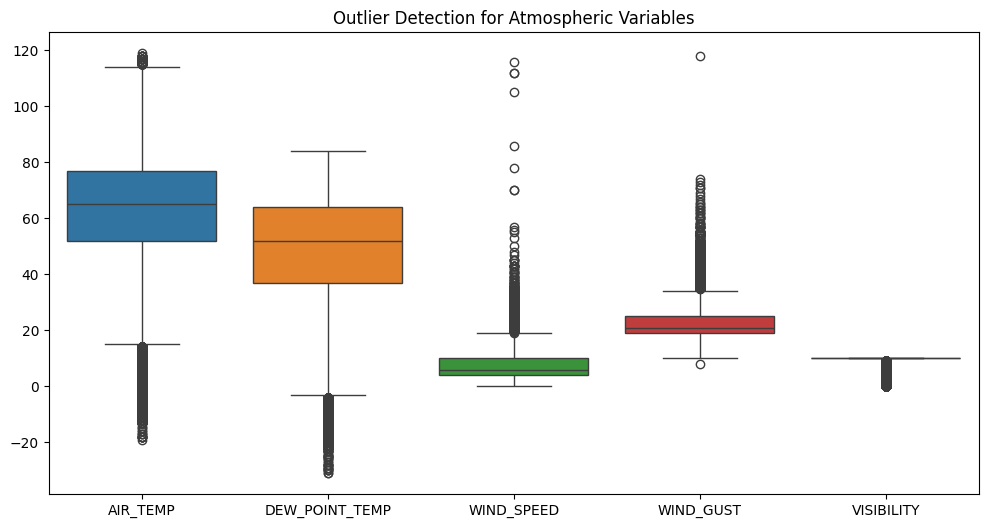

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['AIR_TEMP', 'DEW_POINT_TEMP', 'WIND_SPEED', 'WIND_GUST', 'VISIBILITY']])
plt.title('Outlier Detection for Atmospheric Variables')
plt.show()

### EDA #4: Identifying Potential Relationships: thunderstorm likelihood by month

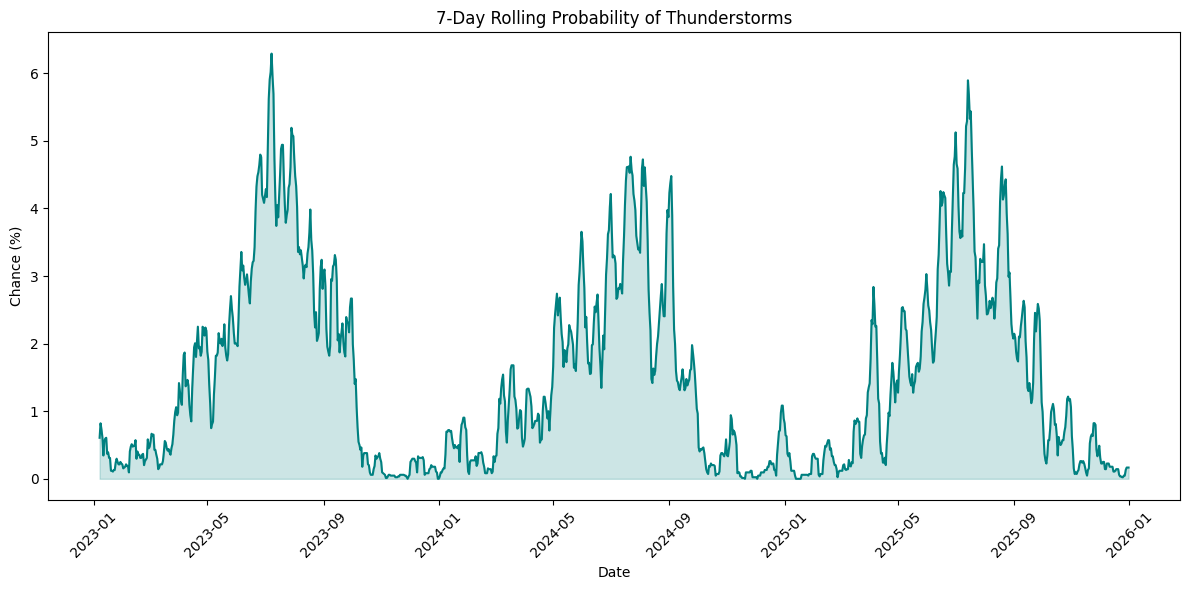

In [10]:
# 1. Get daily average occurrence
df_daily = con.execute("""
    SELECT 
        CAST(valid_ts AS DATE) as date,
        AVG(HAS_THUNDERSTORM) as daily_avg
    FROM weather_cleaned
    GROUP BY 1
    ORDER BY 1
""").df()

# 2. Calculate a 7-day rolling mean to smooth the "trashy" 0/1 data
df_daily['rolling_chance'] = df_daily['daily_avg'].rolling(window=7).mean() * 100

# 3. Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_daily, x='date', y='rolling_chance', color='teal')

plt.fill_between(df_daily['date'], df_daily['rolling_chance'], color='teal', alpha=0.2)
plt.title('7-Day Rolling Probability of Thunderstorms')
plt.ylabel('Chance (%)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()